<a href="https://colab.research.google.com/github/zacw-243L/CHESS/blob/Troll/Humble_Chess_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Humble Chess Bot

Welcome to Humble Chess Bot, a friendly chess opponent built using Python, NumPy, Matplotlib and Google Colab.

You play as **White** against the Beginner Tutorial Bot, which plays as Black. The chessboard is displayed using Matplotlib, while moves are entered through a Google Colab form.

## How to play

### Step 1: Set up the game (run once)

Open this notebook in Google Colab and connect to a runtime.

Run the following code cells **once, in order**, starting from the top:

1. **Install the libraries** (Cell 3): Installs the required Python packages and chess engine.
2. **Initialize the board** (Cell 5): Creates a new chess game and resets the move history.
3. **Board visualization** (Cell 6): Loads the chessboard drawing function and displays the starting position.
4. **Chess engine imports** (Cell 8): Imports the engine-related libraries.
5. **Beginner Bot configuration** (Cell 9): Starts the computer opponent and configures its difficulty.

Once these cells have executed successfully, you're ready to play!

### Step 2: Play chess (repeat every turn)

Find the cell titled **Chess Move Controller** (Cell 11).

This is your main input interface.

1. Enter your move into the `move_text` form field.
2. Press the **Run** button beside the cell.
3. The computer will calculate its response.
4. The updated chessboard will appear below the cell.
5. Enter your next move and run the same cell again.

You can enter moves in standard chess notation, including:

- `e4` to advance the king's pawn.
- `Nf3` to move a knight.
- `e2e4` to specify the starting and destination squares.
- `O-O` to castle kingside when legal.

The program checks whether your move is legal before accepting it.

**Important:** During a game, keep using the Chess Move Controller. Running the board initialization cell again resets your game and erases the current move history.

### Step 3: Finish the game and export your PGN

When the game ends in checkmate, stalemate or another recognized conclusion, the controller displays **Game over!** and the final result.

To save your game history:

1. Scroll down to the **PGN Export** section.
2. Run the PGN imports cell (Cell 13).
3. Run the PGN Exporter cell (Cell 14).
4. Your complete game history will appear in Portable Game Notation (PGN).
5. The program will save a `.pgn` file to Colab's `/content` directory.

To download your PGN, open the **Files** panel on the left side of Colab, locate the generated `chess_game_...pgn` file, and select Download.

The PGN records the sequence of moves, players, date and final result. You can import it into a chess analysis website such as [Lichess](https://lichess.org/paste).

### Step 4: Play again

To begin a new game, rerun the **Initialize the board** cells (Cells 5 and 6). This clears the old chess position and move history.

You can continue using the existing Stockfish engine and Chess Move Controller.

**Remember to download your PGN before starting a new game.** Colab's runtime memory and temporary files can disappear when the runtime disconnects or resets.

---

*Humble Chess Bot wishes you an enjoyable learning experience. Difficulty: Beginner Tutorial Bot :)*

Install the libraries

In [ ]:
!pip -q install python-chess
# Install Stockfish in Colab
!apt-get update -qq
!apt-get install -y -qq stockfish

Initialize the board and visualization

In [ ]:

# @title Initialize Chess Game { display-mode: "form" }

# @markdown ### Chess Game Setup
# @markdown Check the box and run this cell to begin a new game.
# @markdown
# @markdown **Warning:** Starting a new game clears the
# @markdown current position and move history.

start_new_game = True # @param {type:"boolean"}

# Imports
import chess
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# 8x8 matrix: 0 = white, 1 = black
grid = np.indices((8, 8)).sum(axis=0) % 2

if start_new_game:
    board = chess.Board()
    _pgn_exported_for_game = False

    print("New chess game initialized.")
    print("Player: White")
    print("Opponent: Beginner Tutorial Bot :)")

elif "board" in globals():
    print("Existing chess game preserved.")
    print("Moves played:", len(board.move_stack))

else:
    print("Check 'start_new_game' and run this cell.")


In [ ]:

# @title Chessboard Visualization { display-mode: "form", run: "auto" }

# @markdown ### Chessboard Viewer
# @markdown Display the current game position.
# @markdown This cell can be rerun without resetting the game.

show_board = False # @param {type:"boolean"}

def draw_board(board):
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        grid,
        cmap="binary",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    for square, piece in board.piece_map().items():
        x = chess.square_file(square)
        y = 7 - chess.square_rank(square)

        color = "white" if piece.color else "black"
        outline = "black" if piece.color else "white"

        ax.text(
            x, y,
            piece.unicode_symbol(),
            fontsize=34,
            ha="center",
            va="center",
            color=color,
            path_effects=[
                pe.withStroke(
                    linewidth=2,
                    foreground=outline
                )
            ]
        )

    ax.set_xticks(range(8), list("abcdefgh"))
    ax.set_yticks(range(8), list("87654321"))
    ax.tick_params(length=0)

    plt.show()
    plt.close(fig)

# Frontend display control
if show_board:
    if "board" in globals():
        draw_board(board)
        print("Chessboard displayed.")
        print("Moves played:", len(board.move_stack))
    else:
        print("Please initialize the game first.")
else:
    print("Board preview disabled.")


 "minimum"-strength mode

In [110]:

# @title Beginner Tutorial Bot :) { display-mode: "form" }

# @markdown ### Welcome to the Beginner Chess Tutorial!
# @markdown Your friendly chess companion is ready to help
# @markdown you learn the wonderful game of chess.
# @markdown
# @markdown Check the box below and press Run to begin.
# @markdown
# @markdown *Have fun and good luck!*

initialize_bot = True # @param {type:"boolean"}

# Hidden engine implementation
import chess.engine
import os

if initialize_bot:

    if "engine" not in globals():

        # Launch Stockfish
        engine = chess.engine.SimpleEngine.popen_uci(
            "/usr/games/stockfish"
        )

        # "Beginner-friendly" settings
        engine.configure({
            "Skill Level": 20,
            "UCI_LimitStrength": False,
            "Threads": min(2, os.cpu_count() or 1),
            "Hash": 128
        })

        # Thinking time per move
        THINK_TIME = 5.0

        print("Tutorial companion initialized!")
        print("Difficulty: Beginner :)")
        print("Your chess adventure awaits!")

    else:
        print("Your friendly chess companion is already ready!")
        print("You may proceed to the Chess Move Controller.")

else:
    print("Check the box and press Run to start your tutorial!")


Your friendly chess companion is already ready!
You may proceed to the Chess Move Controller.


Chess move form

You played: e4
Computer played: e5


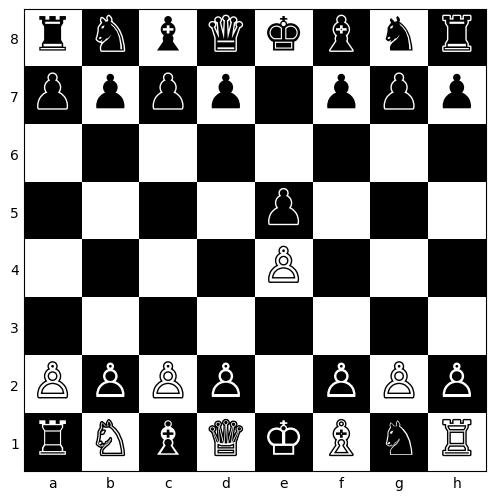

Turn: White
Move number: 2


In [111]:

# @title Chess Move Controller { display-mode: "form" }

move_text = "e4" # @param {type:"string"}

move_text = move_text.strip()

if move_text.lower() == "quit":
    print("Game stopped. Position preserved.")

elif board.is_game_over(claim_draw=True):
    print("Game has already ended.")
    print("Rerun the board initialization cells to start a new game.")

elif not move_text:
    print("Please enter a chess move.")

else:
    try:
        # Accept SAN (e4, Nf3) or UCI (e2e4)
        try:
            move = board.parse_san(move_text)
        except ValueError:
            move = board.parse_uci(move_text)

        # Human moves
        board.push(move)
        print("You played:", move_text)

        # Computer moves if game continues
        if not board.is_game_over(claim_draw=True):

            # The "beginner" computer opponent
            result = engine.play(
                board,
                chess.engine.Limit(time=THINK_TIME)
                )
            computer_move = result.move
            computer_san = board.san(computer_move)
            board.push(computer_move)
            print("Computer played:", computer_san)

    except ValueError:
        print("Illegal move or invalid notation!")
        print("Please try again.")

# Render current position
draw_board(board)

# Check game status
if board.is_game_over(claim_draw=True):
    print("Game over!")
    print("Result:", board.result(claim_draw=True))
    print(board.outcome(claim_draw=True))
else:
    print("Turn:", "White" if board.turn else "Black")
    print("Move number:", board.fullmove_number)

PGN Export (Run After Game Ends)

In [112]:

# @title Save Your Chess Adventure! { display-mode: "form" }

# @markdown ### Congratulations on completing your game!
# @markdown Every chess game tells a story.
# @markdown Preserve yours with a downloadable game record!
# @markdown
# @markdown Check the boxes below and press Run.
# @markdown
# @markdown *Your game will be saved in PGN format.*

export_game = True # @param {type:"boolean"}
download_pgn = True # @param {type:"boolean"}

# Hidden PGN implementation
import chess.pgn
from datetime import datetime
from pathlib import Path

if not export_game:
    print("Check 'export_game' to save your chess adventure!")

elif "board" not in globals():
    print("Please initialize a chess game first.")

elif not board.is_game_over(claim_draw=True):
    print("Your chess adventure is still in progress!")
    print("Finish the game before exporting your PGN.")

elif globals().get("_pgn_exported_for_game", False):
    print("Your game has already been saved!")

    if "_last_pgn_path" in globals():
        print("Saved file:", _last_pgn_path)

        if download_pgn:
            from google.colab import files
            files.download(str(_last_pgn_path))

else:
    # Reconstruct game from move history
    game = chess.pgn.Game.from_board(board)

    # PGN metadata
    game.headers["Event"] = "Humble Chess Bot"
    game.headers["Site"] = "Google Colab"
    game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
    game.headers["White"] = "Human"
    game.headers["Black"] = "Beginner Tutorial Bot :)"
    game.headers["Result"] = board.result(claim_draw=True)

    # Generate PGN
    pgn_text = str(game)

    # Save file
    filename = (
        "Humble_Chess_Game_"
        f"{datetime.now().strftime('%Y%m%d_%H%M%S')}.pgn"
    )

    pgn_path = Path("/content") / filename
    pgn_path.write_text(
        pgn_text + "\n",
        encoding="utf-8"
    )

    # Remember exported file
    _last_pgn_path = pgn_path
    _pgn_exported_for_game = True

    print("Your chess adventure has been preserved!")
    print("Result:", board.result(claim_draw=True))
    print("Total moves:", len(board.move_stack))
    print("Saved file:", filename)

    print("\n========== GAME HISTORY ==========\n")
    print(pgn_text)

    # Optional browser download
    if download_pgn:
        from google.colab import files
        files.download(str(pgn_path))


Your chess adventure is still in progress!
Finish the game before exporting your PGN.


okay this is so gloriously crused .. effective application inside of a SDK called google colab... if its Turing complete it can run anything not make fancy graphs